In [1]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
pd.set_option("display.max_columns", None)
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df_hr_limpio = pd.read_csv("../df_hr_limpio.csv")
df_hr_limpio.head(2)

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41,Yes,Rarely,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4.0,Single,5993.0,8,Yes,11,3,1,0,8,0.0,1,6,4,0,5.0
1,49,No,Frequently,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2.0,Married,5130.0,1,No,23,4,4,1,10,3.0,3,10,7,1,7.0


# CONSULTAS

In [4]:
# ¿Está relacionado el hecho de que los empleados dejen la empresa con su antigüedad?

# 1. Agrupamos por Attrition para comparar las medias de TotalWorkingYears
stats_antiguedad = df_hr_limpio.groupby('attrition')['total_working_years'].agg(['mean', 'median', 'std', 'min', 'max'])

# 2. Segmentamos la antigüedad en rangos para ver en qué etapa de la carrera se van más
# Creamos categorías: 0-5 años (Junior), 6-10 (Middle), 11-20 (Senior), +20 (Expert)
bins = [0, 5, 10, 20, 100]
labels = ['0-5 años', '6-10 años', '11-20 años', 'Más de 20']
df_hr_limpio['rango_experiencia'] = pd.cut(df_hr_limpio['total_working_years'], bins=bins, labels=labels)

# Calculamos el porcentaje de abandono por rango de experiencia
tasa_por_rango = df_hr_limpio.groupby('rango_experiencia')['attrition'].value_counts(normalize=True).unstack() * 100

print("ESTADÍSTICOS DE TOTAL WORKING YEARS POR ABANDONO:")
print(stats_antiguedad)
print("\nPORCENTAJE DE ABANDONO (YES) POR RANGO DE EXPERIENCIA:")
print(tasa_por_rango['Yes'].sort_values(ascending=False))

ESTADÍSTICOS DE TOTAL WORKING YEARS POR ABANDONO:
                mean  median       std  min  max
attrition                                       
No         11.862936    10.0  7.760719    0   38
Yes         8.244726     7.0  7.169204    0   40

PORCENTAJE DE ABANDONO (YES) POR RANGO DE EXPERIENCIA:
rango_experiencia
0-5 años      28.196721
6-10 años     14.991763
11-20 años    11.470588
Más de 20      7.729469
Name: Yes, dtype: float64


C:\Users\W78643925\AppData\Local\Temp\ipykernel_19128\3260958621.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa_por_rango = df_hr_limpio.groupby('rango_experiencia')['attrition'].value_counts(normalize=True).unstack() * 100


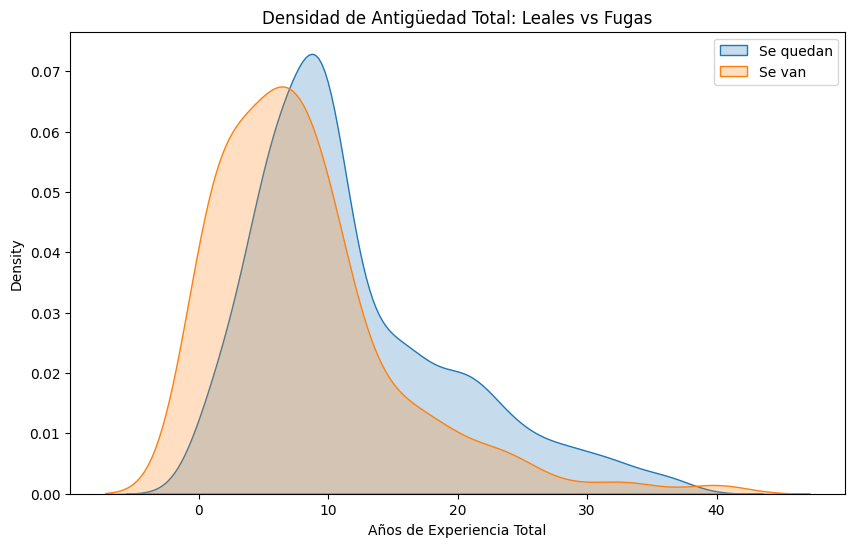

In [5]:
# Gráfico de Densidad 

plt.figure(figsize=(10, 6))
sns.kdeplot(df_hr_limpio[df_hr_limpio['attrition'] == 'No']['total_working_years'], label='Se quedan', fill=True)
sns.kdeplot(df_hr_limpio[df_hr_limpio['attrition'] == 'Yes']['total_working_years'], label='Se van', fill=True)
plt.title('Densidad de Antigüedad Total: Leales vs Fugas')
plt.xlabel('Años de Experiencia Total')
plt.legend()
plt.show()

In [6]:
# ¿Está relacionado el hecho de que los empleados dejen la empresa con la distancia que hay desde su casa hasta su puesto de trabajo?

stats_distancia = df_hr_limpio.groupby('attrition')['distance_from_home'].agg(['mean', 'median', 'std', 'min', 'max'])

# 2. Segmentamos la distancia en rangos para ver el "punto de quiebre"
# Por ejemplo: Cerca (0-5km), Medio (6-15km), Lejos (16-30km)
bins_dist = [0, 5, 15, 30, 100]
labels_dist = ['Cerca (0-5km)', 'Medio (6-15km)', 'Lejos (16-30km)', 'Muy Lejos']
df_hr_limpio['rango_distancia'] = pd.cut(df_hr_limpio['distance_from_home'], bins=bins_dist, labels=labels_dist)

# Calculamos la tasa de abandono por rango de distancia
tasa_distancia = df_hr_limpio.groupby('rango_distancia')['attrition'].value_counts(normalize=True).unstack() * 100

print("ESTADÍSTICOS DE DISTANCIA POR ABANDONO:")
print(stats_distancia)
print("\n% DE ABANDONO POR RANGO DE DISTANCIA:")
print(tasa_distancia['Yes'].sort_values(ascending=False))



ESTADÍSTICOS DE DISTANCIA POR ABANDONO:
                mean  median       std  min  max
attrition                                       
No          8.915653     7.0  8.012633    1   29
Yes        10.632911     9.0  8.452525    1   29

% DE ABANDONO POR RANGO DE DISTANCIA:
rango_distancia
Lejos (16-30km)    20.668693
Medio (6-15km)     16.110020
Cerca (0-5km)      13.765823
Muy Lejos           0.000000
Name: Yes, dtype: float64


C:\Users\W78643925\AppData\Local\Temp\ipykernel_19128\456005199.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa_distancia = df_hr_limpio.groupby('rango_distancia')['attrition'].value_counts(normalize=True).unstack() * 100


C:\Users\W78643925\AppData\Local\Temp\ipykernel_19128\2011333220.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rango_distancia', y='Yes', data=tasa_distancia.reset_index(), palette='magma')


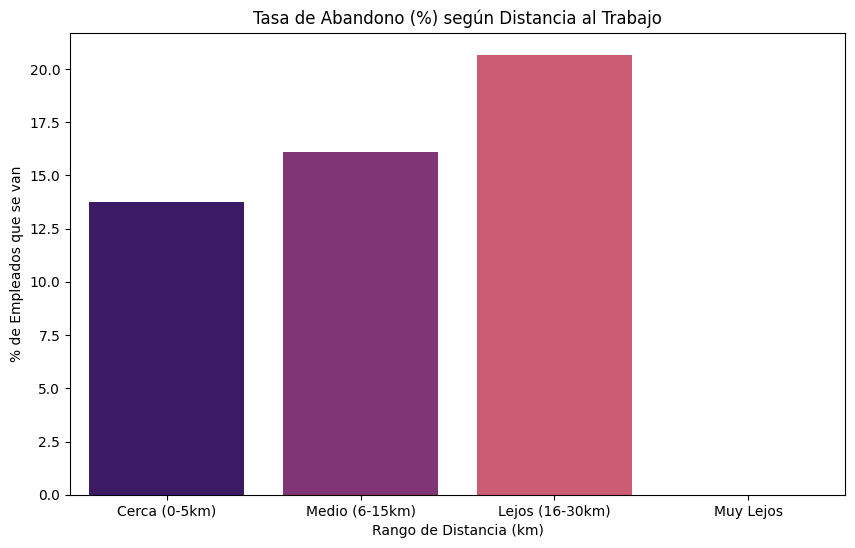

In [7]:
plt.figure(figsize=(10, 6))
# Graficamos el porcentaje de 'Yes' por cada rango
sns.barplot(x='rango_distancia', y='Yes', data=tasa_distancia.reset_index(), palette='magma')
plt.title('Tasa de Abandono (%) según Distancia al Trabajo')
plt.ylabel('% de Empleados que se van')
plt.xlabel('Rango de Distancia (km)')
plt.show()

In [8]:
# Está relacionado el compromiso del trabajador con la tasa de abandono?

# Calculamos el porcentaje de abandono para cada nivel de Job Involvement
# Esto genera una serie con el % de 'Yes' y 'No' por nivel
tasa_compromiso = (df_hr_limpio.groupby('job_involvement')['attrition']
                   .value_counts(normalize=True)
                   .rename('percentage')
                   .reset_index())

# Multiplicamos por 100 para que sea legible como porcentaje
tasa_compromiso['percentage'] *= 100

# Filtramos solo para ver el porcentaje de los que se van ('Yes')
solo_fugas = tasa_compromiso[tasa_compromiso['attrition'] == 'Yes']

print("Porcentaje de fuga por nivel de involucración:")
print(solo_fugas[['job_involvement', 'percentage']])


Porcentaje de fuga por nivel de involucración:
   job_involvement  percentage
1                1   33.734940
3                2   18.933333
5                3   14.400922
7                4    9.027778


C:\Users\W78643925\AppData\Local\Temp\ipykernel_12060\1987158396.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=solo_fugas, x='job_involvement', y='percentage', palette='Reds_r')


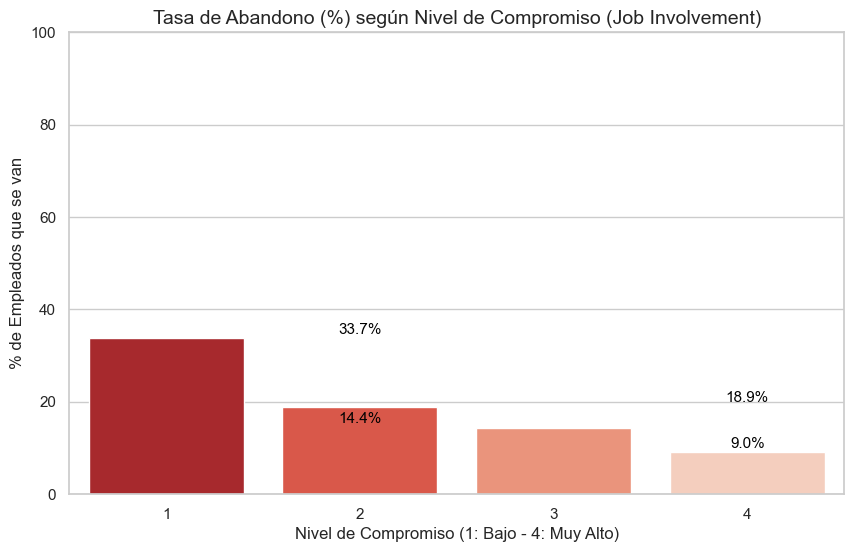

In [24]:
plt.figure(figsize=(10, 6))

# Usamos la paleta 'Reds_r' para enfatizar que el nivel bajo (1) es el más crítico
sns.barplot(data=solo_fugas, x='job_involvement', y='percentage', palette='Reds_r')

plt.title('Tasa de Abandono (%) según Nivel de Compromiso (Job Involvement)', fontsize=14)
plt.xlabel('Nivel de Compromiso (1: Bajo - 4: Muy Alto)', fontsize=12)
plt.ylabel('% de Empleados que se van', fontsize=12)
plt.ylim(0, 100) # Mantenemos la escala al 100 para no exagerar las diferencias

# Añadimos etiquetas de valor sobre las barras para mayor claridad técnica
for index, row in solo_fugas.iterrows():
    plt.text(row.name % 4, row.percentage + 1, f'{row.percentage:.1f}%', 
             color='black', ha="center", fontsize=11)

plt.show()

In [9]:
# Está relacionado la cantidad de formación que  reciben los empleados con la tasa de abandono?

# 1. Calculamos el porcentaje de abandono para cada número de formaciones
tasa_formacion = (df_hr_limpio.groupby('training_times_last_year')['attrition']
                   .value_counts(normalize=True)
                   .rename('percentage')
                   .reset_index())

# Multiplicamos por 100 para formato porcentaje
tasa_formacion['percentage'] *= 100

# 2. Filtramos solo para ver los que se van ('Yes')
fuga_formacion = tasa_formacion[tasa_formacion['attrition'] == 'Yes']

print("Porcentaje de fuga según número de formaciones recibidas:")
print(fuga_formacion[['training_times_last_year', 'percentage']])

Porcentaje de fuga según número de formaciones recibidas:
    training_times_last_year  percentage
1                        0.0   28.301887
3                        1.0   12.307692
5                        2.0   18.532819
7                        3.0   13.627993
9                        4.0   21.367521
11                       5.0   11.711712
13                       6.0    9.523810


C:\Users\W78643925\AppData\Local\Temp\ipykernel_19128\143494668.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=fuga_formacion, x='training_times_last_year', y='percentage', palette='viridis')


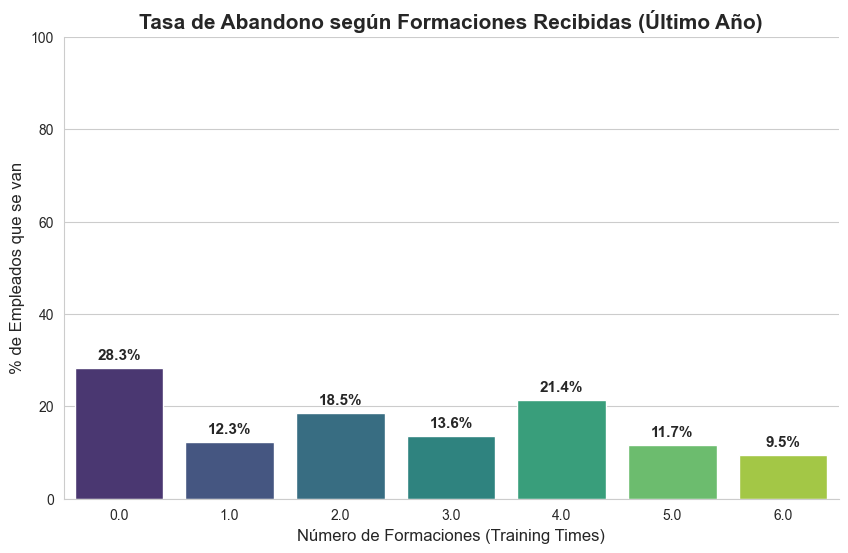

In [10]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Creamos el gráfico de barras
ax = sns.barplot(data=fuga_formacion, x='training_times_last_year', y='percentage', palette='viridis')

# Títulos y etiquetas
plt.title('Tasa de Abandono según Formaciones Recibidas (Último Año)', fontsize=15, fontweight='bold')
plt.xlabel('Número de Formaciones (Training Times)', fontsize=12)
plt.ylabel('% de Empleados que se van', fontsize=12)
plt.ylim(0, 100)

# Añadimos etiquetas de valor sobre las barras
for p in ax.patches:
    if p.get_height() > 0: # Evitar etiquetas en barras de 0%
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=11, fontweight='bold')

sns.despine()
plt.show()